RainClass
0    14375
1     2393
Name: count, dtype: int64
RainClass
0    85.728769
1    14.271231
Name: proportion, dtype: float64
X_train: (12389, 30, 9)
y_train: (12389,)
Rainy days in train: 1652
Dry days in train: 10737
Class weights: {0: np.float64(0.5769302412219428), 1: np.float64(3.749697336561743)}


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 30, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 28, 64)    │      1,792 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_embedding   │ (None, 1, 4)      │         20 │ station_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 64)        │     33,024 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 4)         │          0 │ station_embeddin… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 68)        │          0 │ lstm_6[0][0],     │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      4,416 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,317 (153.58 KB)

 Trainable params: 39,317 (153.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6270 - loss: 0.5418 - val_accuracy: 0.5415 - val_loss: 0.6538
Epoch 2/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6407 - loss: 0.5131 - val_accuracy: 0.5938 - val_loss: 0.5755
Epoch 3/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6745 - loss: 0.4822 - val_accuracy: 0.6965 - val_loss: 0.5730
Epoch 4/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7214 - loss: 0.4606 - val_accuracy: 0.7368 - val_loss: 0.4959
Epoch 5/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7307 - loss: 0.4558 - val_accuracy: 0.6695 - val_loss: 0.5853
Epoch 6/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7331 - loss: 0.4485 - val_accuracy: 0.6214 - val_loss: 0.6009
Epoch 7/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7323 - loss: 0.4430 - val_accuracy: 0.7085 - val_loss: 0.5372
Epoch 8/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7395 - loss: 0.4406 - val_accu

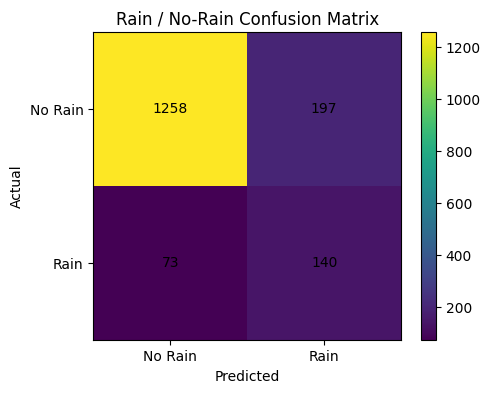

Saved model: cnn_lstm_rain_classifier.keras


In [8]:
# =====================================================
# RAIN / NO-RAIN CLASSIFICATION EXPERIMENT
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Embedding, GlobalMaxPooling1D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_excel("final_filled_climate_cleaned.xlsx")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])
df = df.sort_values(["Station", "Date"]).reset_index(drop=True)


# =====================================================
# 2. CREATE RAIN CLASS
# =====================================================

df["RainClass"] = (df["Rain"] > 0).astype(int)

print(df["RainClass"].value_counts())
print(df["RainClass"].value_counts(normalize=True) * 100)


# =====================================================
# 3. TEMPORAL FEATURES
# =====================================================

df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Year"] = df["Date"].dt.year


# =====================================================
# 4. STATION ENCODING
# =====================================================

le = LabelEncoder()
df["Station_enc"] = le.fit_transform(df["Station"])


# =====================================================
# 5. FEATURES AND TARGET
# =====================================================

features = [
    "Temp",
    "RH",
    "Wind",
    "Rain",
    "PRESS",
    "SUNSHINE",
    "Month",
    "Week",
    "DayOfWeek"
]

target = "RainClass"


# =====================================================
# 6. CHRONOLOGICAL SPLIT
# =====================================================

train_df = df[df["Year"] <= 2022].copy()
val_df   = df[df["Year"] == 2023].copy()
test_df  = df[df["Year"] == 2024].copy()


# =====================================================
# 7. SCALING
# =====================================================

X_scaler = MinMaxScaler()
X_scaler.fit(train_df[features])

train_X = X_scaler.transform(train_df[features])
val_X   = X_scaler.transform(val_df[features])
test_X  = X_scaler.transform(test_df[features])

train_y = train_df[target].values
val_y   = val_df[target].values
test_y  = test_df[target].values

train_station = train_df["Station_enc"].values
val_station   = val_df["Station_enc"].values
test_station  = test_df["Station_enc"].values


# =====================================================
# 8. CREATE 30-DAY SEQUENCES
# =====================================================

SEQ_LEN = 30

def create_class_sequences(X, y, station_ids, seq_len=30):
    X_seq = []
    S_seq = []
    y_seq = []

    for station in np.unique(station_ids):
        idx = np.where(station_ids == station)[0]

        X_station = X[idx]
        y_station = y[idx]

        for i in range(len(X_station) - seq_len):
            X_seq.append(X_station[i:i + seq_len])
            S_seq.append(station)
            y_seq.append(y_station[i + seq_len])

    return np.array(X_seq), np.array(S_seq), np.array(y_seq)


X_train, S_train, y_train = create_class_sequences(
    train_X, train_y, train_station, SEQ_LEN
)

X_val, S_val, y_val = create_class_sequences(
    val_X, val_y, val_station, SEQ_LEN
)

X_test, S_test, y_test = create_class_sequences(
    test_X, test_y, test_station, SEQ_LEN
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Rainy days in train:", y_train.sum())
print("Dry days in train:", len(y_train) - y_train.sum())


# =====================================================
# 9. CLASS WEIGHTS
# =====================================================

dry_count = np.sum(y_train == 0)
rain_count = np.sum(y_train == 1)

total = len(y_train)

class_weight = {
    0: total / (2 * dry_count),
    1: total / (2 * rain_count)
}

print("Class weights:", class_weight)


# =====================================================
# 10. BUILD CNN-LSTM CLASSIFIER
# =====================================================

num_features = X_train.shape[2]
num_stations = df["Station_enc"].nunique()

seq_input = Input(shape=(SEQ_LEN, num_features), name="sequence_input")

x = Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    padding="valid"
)(seq_input)

x = LSTM(
    units=64,
    return_sequences=False
)(x)

station_input = Input(shape=(1,), name="station_input")

s = Embedding(
    input_dim=num_stations,
    output_dim=4,
    name="station_embedding"
)(station_input)

s = GlobalMaxPooling1D()(s)

combined = Concatenate()([x, s])

z = Dense(64, activation="relu")(combined)
z = Dropout(0.2)(z)

output = Dense(1, activation="sigmoid")(z)

clf_model = Model(
    inputs=[seq_input, station_input],
    outputs=output
)

clf_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

clf_model.summary()


# =====================================================
# 11. TRAIN CLASSIFIER
# =====================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = clf_model.fit(
    [X_train, S_train],
    y_train,
    validation_data=([X_val, S_val], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)


# =====================================================
# 12. PREDICTION
# =====================================================

y_prob = clf_model.predict([X_test, S_test]).ravel()

threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)


# =====================================================
# 13. EVALUATION
# =====================================================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Rain", "Rain"]
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


# =====================================================
# 14. PLOT CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Rain / No-Rain Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Rain", "Rain"])
plt.yticks([0, 1], ["No Rain", "Rain"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# =====================================================
# 15. SAVE MODEL
# =====================================================

clf_model.save("cnn_lstm_rain_classifier.keras")

print("Saved model: cnn_lstm_rain_classifier.keras")

RainClass
0    14375
1     2393
Name: count, dtype: int64
RainClass
0    85.728769
1    14.271231
Name: proportion, dtype: float64
X_train: (12389, 30, 9)
y_train: (12389,)
Rainy days in train: 1652
Dry days in train: 10737
Class weights: {0: np.float64(0.5769302412219428), 1: np.float64(3.749697336561743)}


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 30, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 28, 64)    │      1,792 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_embedding   │ (None, 1, 4)      │         20 │ station_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ (None, 64)        │     33,024 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 4)         │          0 │ station_embeddin… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 68)        │          0 │ lstm_7[0][0],     │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      4,416 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,317 (153.58 KB)

 Trainable params: 39,317 (153.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6470 - loss: 0.5428 - val_accuracy: 0.5469 - val_loss: 0.6146
Epoch 2/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6375 - loss: 0.5085 - val_accuracy: 0.6340 - val_loss: 0.5413
Epoch 3/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6950 - loss: 0.4804 - val_accuracy: 0.6298 - val_loss: 0.5769
Epoch 4/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7202 - loss: 0.4595 - val_accuracy: 0.7686 - val_loss: 0.4632
Epoch 5/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7270 - loss: 0.4584 - val_accuracy: 0.6136 - val_loss: 0.6087
Epoch 6/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7343 - loss: 0.4471 - val_accuracy: 0.6647 - val_loss: 0.5741
Epoch 7/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7394 - loss: 0.4482 - val_accuracy: 0.6821 - val_loss: 0.5492
Epoch 8/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7486 - loss: 0.4401 - val_accu

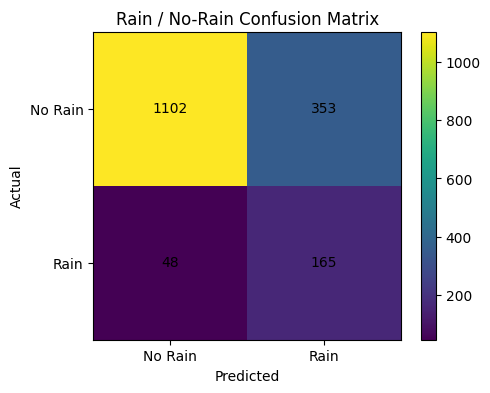

Saved model: cnn_lstm_rain_classifier.keras


In [9]:
# =====================================================
# RAIN / NO-RAIN CLASSIFICATION EXPERIMENT
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Embedding, GlobalMaxPooling1D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping


# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_excel("final_filled_climate_cleaned.xlsx")

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df = df.dropna(subset=["Date"])
df = df.sort_values(["Station", "Date"]).reset_index(drop=True)


# =====================================================
# 2. CREATE RAIN CLASS
# =====================================================

df["RainClass"] = (df["Rain"] > 0).astype(int)

print(df["RainClass"].value_counts())
print(df["RainClass"].value_counts(normalize=True) * 100)


# =====================================================
# 3. TEMPORAL FEATURES
# =====================================================

df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Year"] = df["Date"].dt.year


# =====================================================
# 4. STATION ENCODING
# =====================================================

le = LabelEncoder()
df["Station_enc"] = le.fit_transform(df["Station"])


# =====================================================
# 5. FEATURES AND TARGET
# =====================================================

features = [
    "Temp",
    "RH",
    "Wind",
    "Rain",
    "PRESS",
    "SUNSHINE",
    "Month",
    "Week",
    "DayOfWeek"
]

target = "RainClass"


# =====================================================
# 6. CHRONOLOGICAL SPLIT
# =====================================================

train_df = df[df["Year"] <= 2022].copy()
val_df   = df[df["Year"] == 2023].copy()
test_df  = df[df["Year"] == 2024].copy()


# =====================================================
# 7. SCALING
# =====================================================

X_scaler = MinMaxScaler()
X_scaler.fit(train_df[features])

train_X = X_scaler.transform(train_df[features])
val_X   = X_scaler.transform(val_df[features])
test_X  = X_scaler.transform(test_df[features])

train_y = train_df[target].values
val_y   = val_df[target].values
test_y  = test_df[target].values

train_station = train_df["Station_enc"].values
val_station   = val_df["Station_enc"].values
test_station  = test_df["Station_enc"].values


# =====================================================
# 8. CREATE 30-DAY SEQUENCES
# =====================================================

SEQ_LEN = 30

def create_class_sequences(X, y, station_ids, seq_len=30):
    X_seq = []
    S_seq = []
    y_seq = []

    for station in np.unique(station_ids):
        idx = np.where(station_ids == station)[0]

        X_station = X[idx]
        y_station = y[idx]

        for i in range(len(X_station) - seq_len):
            X_seq.append(X_station[i:i + seq_len])
            S_seq.append(station)
            y_seq.append(y_station[i + seq_len])

    return np.array(X_seq), np.array(S_seq), np.array(y_seq)


X_train, S_train, y_train = create_class_sequences(
    train_X, train_y, train_station, SEQ_LEN
)

X_val, S_val, y_val = create_class_sequences(
    val_X, val_y, val_station, SEQ_LEN
)

X_test, S_test, y_test = create_class_sequences(
    test_X, test_y, test_station, SEQ_LEN
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Rainy days in train:", y_train.sum())
print("Dry days in train:", len(y_train) - y_train.sum())


# =====================================================
# 9. CLASS WEIGHTS
# =====================================================

dry_count = np.sum(y_train == 0)
rain_count = np.sum(y_train == 1)

total = len(y_train)

class_weight = {
    0: total / (2 * dry_count),
    1: total / (2 * rain_count)
}

print("Class weights:", class_weight)


# =====================================================
# 10. BUILD CNN-LSTM CLASSIFIER
# =====================================================

num_features = X_train.shape[2]
num_stations = df["Station_enc"].nunique()

seq_input = Input(shape=(SEQ_LEN, num_features), name="sequence_input")

x = Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    padding="valid"
)(seq_input)

x = LSTM(
    units=64,
    return_sequences=False
)(x)

station_input = Input(shape=(1,), name="station_input")

s = Embedding(
    input_dim=num_stations,
    output_dim=4,
    name="station_embedding"
)(station_input)

s = GlobalMaxPooling1D()(s)

combined = Concatenate()([x, s])

z = Dense(64, activation="relu")(combined)
z = Dropout(0.2)(z)

output = Dense(1, activation="sigmoid")(z)

clf_model = Model(
    inputs=[seq_input, station_input],
    outputs=output
)

clf_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

clf_model.summary()


# =====================================================
# 11. TRAIN CLASSIFIER
# =====================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = clf_model.fit(
    [X_train, S_train],
    y_train,
    validation_data=([X_val, S_val], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)


# =====================================================
# 12. PREDICTION
# =====================================================

y_prob = clf_model.predict([X_test, S_test]).ravel()

threshold = 0.4
y_pred = (y_prob >= threshold).astype(int)


# =====================================================
# 13. EVALUATION
# =====================================================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Rain", "Rain"]
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


# =====================================================
# 14. PLOT CONFUSION MATRIX
# =====================================================

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Rain / No-Rain Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["No Rain", "Rain"])
plt.yticks([0, 1], ["No Rain", "Rain"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# =====================================================
# 15. SAVE MODEL
# =====================================================

clf_model.save("cnn_lstm_rain_classifier.keras")

print("Saved model: cnn_lstm_rain_classifier.keras")